In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# =========================
# 1. 파일 읽기
# =========================

hospital_A = pd.read_csv("hospital_A.csv")
hospital_B = pd.read_csv("hospital_B.csv")
hospital_C = pd.read_csv("hospital_C.csv")

# 세 병원 전체 원본 데이터
diabetic_data = pd.read_csv("diabetic_data.csv")

print("hospital_A:", hospital_A.shape)
print("hospital_B:", hospital_B.shape)
print("hospital_C:", hospital_C.shape)
print("diabetic_data:", diabetic_data.shape)

hospital_A: (33922, 51)
hospital_B: (33922, 51)
hospital_C: (33922, 51)
diabetic_data: (101766, 50)


In [ ]:
# =========================
# 2. 변수 설정
# =========================

features = [
    'race',
    'gender',
    'age',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'max_glu_serum',
    'A1Cresult',
    'insulin',
    'change',
    'diabetesMed'
]

target = "readmitted"

use_cols = features + [target]

In [ ]:
# =========================
# 3. 불필요한 인덱스 컬럼 제거
# =========================

for name, df in {
    "hospital_A": hospital_A,
    "hospital_B": hospital_B,
    "hospital_C": hospital_C,
    "diabetic_data": diabetic_data
}.items():
    unnamed_cols = [col for col in df.columns if col.startswith("Unnamed")]

    if unnamed_cols:
        df.drop(columns=unnamed_cols, inplace=True)
        print(f"{name} 제거한 컬럼:", unnamed_cols)

In [ ]:
# =========================
# 4. 필요한 컬럼만 선택
# =========================

hospital_A = hospital_A[use_cols].copy()
hospital_B = hospital_B[use_cols].copy()
hospital_C = hospital_C[use_cols].copy()

# 전체 원본도 확인용으로 동일 컬럼만 선택
diabetic_data = diabetic_data[use_cols].copy()

print("필요 컬럼만 선택")
print("hospital_A:", hospital_A.shape)
print("hospital_B:", hospital_B.shape)
print("hospital_C:", hospital_C.shape)
print("diabetic_data:", diabetic_data.shape)

필요 컬럼만 선택
hospital_A: (33922, 20)
hospital_B: (33922, 20)
hospital_C: (33922, 20)
diabetic_data: (101766, 20)


In [ ]:
# =========================
# 5. 병원 구분 컬럼 추가 후 통합
# =========================

hospital_A["hospital_id"] = "A"
hospital_B["hospital_id"] = "B"
hospital_C["hospital_id"] = "C"

hospital_all = pd.concat(
    [hospital_A, hospital_B, hospital_C],
    axis=0,
    ignore_index=True
)

print("병원 A/B/C 통합 크기:", hospital_all.shape)
print("전체 diabetic_data 크기:", diabetic_data.shape)

print("A+B+C 행 수:", len(hospital_A) + len(hospital_B) + len(hospital_C))
print("diabetic_data 행 수:", len(diabetic_data))

병원 A/B/C 통합 크기: (101766, 21)
전체 diabetic_data 크기: (101766, 20)
A+B+C 행 수: 101766
diabetic_data 행 수: 101766


In [ ]:
# =========================
# 6. 결측치 표시 통일
# =========================

missing_values = ["?", "None", "none", "NULL", "null", "", " ", "NaN", "nan"]

hospital_all = hospital_all.replace(missing_values, np.nan)

print("결측치 개수 확인")
print(hospital_all.isna().sum().sort_values(ascending=False))

결측치 개수 확인
max_glu_serum               96420
A1Cresult                   84748
race                         2273
gender                          0
age                             0
discharge_disposition_id        0
admission_type_id               0
admission_source_id             0
time_in_hospital                0
num_medications                 0
number_outpatient               0
num_lab_procedures              0
num_procedures                  0
number_inpatient                0
number_emergency                0
number_diagnoses                0
insulin                         0
change                          0
diabetesMed                     0
readmitted                      0
hospital_id                     0
dtype: int64


In [ ]:
# =========================
# 7. target 변환
# =========================

print("target 변환 전 분포")
print(hospital_all[target].value_counts(dropna=False))

hospital_all[target] = hospital_all[target].apply(
    lambda x: 1 if x == "<30" else 0
)

hospital_all[target] = hospital_all[target].astype(int)

print("\ntarget 변환 후 분포")
print(hospital_all[target].value_counts())

target 변환 전 분포
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

target 변환 후 분포
readmitted
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
# =========================
# 8. 수치형 / 범주형 컬럼 구분
# =========================

id_col = "hospital_id"

numeric_cols = hospital_all[features].select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_cols = [
    col for col in features
    if col not in numeric_cols
]

print("수치형 컬럼:", numeric_cols)
print("범주형 컬럼:", categorical_cols)

수치형 컬럼: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
범주형 컬럼: ['race', 'gender', 'age', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed']


In [ ]:
# =========================
# 9. 수치형 결측치 처리
# =========================

for col in numeric_cols:
    median_value = hospital_all[col].median()
    hospital_all[col] = hospital_all[col].fillna(median_value)

print("수치형 결측치 처리 완료")

수치형 결측치 처리 완료


In [ ]:
# =========================
# 10. 범주형 결측치 처리 + 숫자 인코딩
# =========================

for col in categorical_cols:
    hospital_all[col] = hospital_all[col].fillna("Unknown").astype(str)

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

hospital_all[categorical_cols] = encoder.fit_transform(
    hospital_all[categorical_cols]
)

hospital_all[categorical_cols] = hospital_all[categorical_cols].astype(int)

print("범주형 숫자 인코딩 완료")

범주형 숫자 인코딩 완료


In [ ]:
# =========================
# 11. 최종 확인
# =========================

check_df = hospital_all.drop(columns=[id_col])

non_numeric_cols = check_df.select_dtypes(exclude=[np.number]).columns.tolist()
missing_count = check_df.isna().sum().sum()

print("숫자가 아닌 컬럼:", non_numeric_cols)
print("전체 결측치 개수:", missing_count)
print("최종 데이터 크기:", check_df.shape)

if len(non_numeric_cols) == 0 and missing_count == 0:
    print("전처리 완료")
else:
    print("확인 필요")

숫자가 아닌 컬럼: []
전체 결측치 개수: 0
최종 데이터 크기: (101766, 20)
전처리 완료


In [ ]:
# =========================
# 12. 병원별 숫자형 전처리 데이터 생성
# =========================

hospital_A_num = hospital_all[hospital_all[id_col] == "A"].drop(
    columns=[id_col]
).reset_index(drop=True)

hospital_B_num = hospital_all[hospital_all[id_col] == "B"].drop(
    columns=[id_col]
).reset_index(drop=True)

hospital_C_num = hospital_all[hospital_all[id_col] == "C"].drop(
    columns=[id_col]
).reset_index(drop=True)

diabetic_data_num = hospital_all.drop(columns=[id_col]).reset_index(drop=True)

print("hospital_A_num:", hospital_A_num.shape)
print("hospital_B_num:", hospital_B_num.shape)
print("hospital_C_num:", hospital_C_num.shape)
print("diabetic_data_num:", diabetic_data_num.shape)

hospital_A_num: (33922, 20)
hospital_B_num: (33922, 20)
hospital_C_num: (33922, 20)
diabetic_data_num: (101766, 20)


In [ ]:
# =========================
# 13. target 분포 확인
# =========================

print("A target 분포")
print(hospital_A_num[target].value_counts())

print("\nB target 분포")
print(hospital_B_num[target].value_counts())

print("\nC target 분포")
print(hospital_C_num[target].value_counts())

print("\n전체 target 분포")
print(diabetic_data_num[target].value_counts())

A target 분포
readmitted
0    30136
1     3786
Name: count, dtype: int64

B target 분포
readmitted
0    30136
1     3786
Name: count, dtype: int64

C target 분포
readmitted
0    30137
1     3785
Name: count, dtype: int64

전체 target 분포
readmitted
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
# =========================
# 14. CSV 저장
# =========================

hospital_A_num.to_csv("hospital_A_preprocessed.csv", index=False)
hospital_B_num.to_csv("hospital_B_preprocessed.csv", index=False)
hospital_C_num.to_csv("hospital_C_preprocessed.csv", index=False)
diabetic_data_num.to_csv("diabetic_data_preprocessed.csv", index=False)

print("CSV 저장 완료")

CSV 저장 완료


trian/test 데이터셋 생성

In [1]:
import pandas as pd
import numpy as np
import os
import shutil
from sklearn.preprocessing import StandardScaler
from google.colab import files

# =========================
# 1. 파일 불러오기
# =========================

hospital_A_num = pd.read_csv("hospital_A_preprocessed.csv")
hospital_B_num = pd.read_csv("hospital_B_preprocessed.csv")
hospital_C_num = pd.read_csv("hospital_C_preprocessed.csv")

# =========================
# 2. 병원별 train/test 분할
# =========================

from sklearn.model_selection import train_test_split

features = [
    'race',
    'gender',
    'age',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'max_glu_serum',
    'A1Cresult',
    'insulin',
    'change',
    'diabetesMed'
]

target = "readmitted"

A_train, A_test = train_test_split(
    hospital_A_num,
    test_size=0.2,
    random_state=42,
    stratify=hospital_A_num[target]
)

B_train, B_test = train_test_split(
    hospital_B_num,
    test_size=0.2,
    random_state=42,
    stratify=hospital_B_num[target]
)

C_train, C_test = train_test_split(
    hospital_C_num,
    test_size=0.2,
    random_state=42,
    stratify=hospital_C_num[target]
)

print("병원별 train/test 분할 완료")
print("A_train:", A_train.shape, "A_test:", A_test.shape)
print("B_train:", B_train.shape, "B_test:", B_test.shape)
print("C_train:", C_train.shape, "C_test:", C_test.shape)

병원별 train/test 분할 완료
A_train: (27137, 20) A_test: (6785, 20)
B_train: (27137, 20) B_test: (6785, 20)
C_train: (27137, 20) C_test: (6785, 20)


In [ ]:
# =========================
# 3. central_train / common_test 생성
# =========================

central_train = pd.concat(
    [A_train, B_train, C_train],
    axis=0,
    ignore_index=True
)

common_test = pd.concat(
    [A_test, B_test, C_test],
    axis=0,
    ignore_index=True
)

print("central_train / common_test 생성 완료")
print("central_train:", central_train.shape)
print("common_test:", common_test.shape)

print("\ncentral_train target 분포")
print(central_train[target].value_counts())

print("\ncommon_test target 분포")
print(common_test[target].value_counts())

central_train / common_test 생성 완료
central_train: (81411, 20)
common_test: (20355, 20)

central_train target 분포
readmitted
0    72325
1     9086
Name: count, dtype: int64

common_test target 분포
readmitted
0    18084
1     2271
Name: count, dtype: int64


In [ ]:
# =========================
# 4. 공통 스케일링
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# train 데이터에만 fit
scaler.fit(central_train[features])

def make_float_X_y(df):
    X = scaler.transform(df[features])
    y = df[target].astype(int).values
    return X, y

# 중앙집중식 학습용
X_train_central, y_train_central = make_float_X_y(central_train)

# 공통 테스트셋
X_test_common, y_test_common = make_float_X_y(common_test)

# FL 병원별 로컬 학습용
X_A_train, y_A_train = make_float_X_y(A_train)
X_B_train, y_B_train = make_float_X_y(B_train)
X_C_train, y_C_train = make_float_X_y(C_train)

print("공통 스케일링 완료")
print("X_train_central:", X_train_central.shape)
print("X_test_common:", X_test_common.shape)
print("X_A_train:", X_A_train.shape)
print("X_B_train:", X_B_train.shape)
print("X_C_train:", X_C_train.shape)

공통 스케일링 완료
X_train_central: (81411, 19)
X_test_common: (20355, 19)
X_A_train: (27137, 19)
X_B_train: (27137, 19)
X_C_train: (27137, 19)


성능 평가 모델

In [2]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, y_true, y_pred, elapsed_time=None, communication_mb=None):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n===== {name} =====")
    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)

    if elapsed_time is not None:
        print("Time     :", elapsed_time, "seconds")

    if communication_mb is not None:
        print("Comm. MB :", communication_mb)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "model": name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "time_sec": elapsed_time,
        "communication_mb": communication_mb
    }

results = []

중앙집중식 Logistic Regression

In [ ]:
start_time = time.time()

central_lr = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

central_lr.fit(X_train_central, y_train_central)

end_time = time.time()
central_lr_time = end_time - start_time

y_pred_central_lr = central_lr.predict(X_test_common)

result_central_lr = evaluate_model(
    name="Centralized Logistic Regression",
    y_true=y_test_common,
    y_pred=y_pred_central_lr,
    elapsed_time=central_lr_time,
    communication_mb=0
)

results.append(result_central_lr)


===== Centralized Logistic Regression =====
Accuracy : 0.6728567919430115
Precision: 0.17380315194766577
Recall   : 0.5147512109202994
F1-score : 0.2598643992441925
Time     : 0.27818989753723145 seconds
Comm. MB : 0

Confusion Matrix
[[12527  5557]
 [ 1102  1169]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     18084
           1       0.17      0.51      0.26      2271

    accuracy                           0.67     20355
   macro avg       0.55      0.60      0.52     20355
weighted avg       0.84      0.67      0.73     20355



중앙집중식 SGD Logistic Regression

In [ ]:
start_time = time.time()

central_sgd = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.0001,
    max_iter=30,
    tol=None,
    random_state=42,
    learning_rate="constant",
    eta0=0.005,
    class_weight="balanced"
)

central_sgd.fit(X_train_central, y_train_central)

end_time = time.time()
central_sgd_time = end_time - start_time

y_pred_central_sgd = central_sgd.predict(X_test_common)

result_central_sgd = evaluate_model(
    name="Centralized SGD Logistic Regression",
    y_true=y_test_common,
    y_pred=y_pred_central_sgd,
    elapsed_time=central_sgd_time,
    communication_mb=0
)

results.append(result_central_sgd)


===== Centralized SGD Logistic Regression =====
Accuracy : 0.5847211987226726
Precision: 0.15331987438313144
Recall   : 0.6019374724790841
F1-score : 0.24439081076249217
Time     : 1.1513285636901855 seconds
Comm. MB : 0

Confusion Matrix
[[10535  7549]
 [  904  1367]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.58      0.71     18084
           1       0.15      0.60      0.24      2271

    accuracy                           0.58     20355
   macro avg       0.54      0.59      0.48     20355
weighted avg       0.84      0.58      0.66     20355



FL SGD FedAvg

In [ ]:
# =========================
# FL SGD FedAvg
# =========================

def sigmoid(z):
    z = np.clip(z, -500, 500)  # overflow 방지
    return 1 / (1 + np.exp(-z))

def predict_proba_lr(X, w, b):
    return sigmoid(np.dot(X, w) + b)

def predict_lr(X, w, b, threshold=0.5):
    proba = predict_proba_lr(X, w, b)
    return (proba >= threshold).astype(int)

def local_sgd_train_weighted(
    X, y, w, b,
    lr=0.01,
    local_epochs=1,
    batch_size=256,
    class_weight=None
):
    """
    class weight를 반영한 병원별 로컬 SGD 학습
    """
    n_samples = X.shape[0]
    w_local = w.copy()
    b_local = b

    for epoch in range(local_epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)

        for start in range(0, n_samples, batch_size):
            batch_idx = indices[start:start + batch_size]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]

            y_prob = predict_proba_lr(X_batch, w_local, b_local)
            error = y_prob - y_batch

            if class_weight is not None:
                sample_weights = np.where(
                    y_batch == 1,
                    class_weight[1],
                    class_weight[0]
                )
                error = error * sample_weights

            grad_w = np.dot(X_batch.T, error) / len(y_batch)
            grad_b = np.mean(error)

            w_local -= lr * grad_w
            b_local -= lr * grad_b

    return w_local, b_local

def fedavg_weighted(client_params, client_sizes):
    """
    데이터 수 기준 FedAvg
    """
    total_size = sum(client_sizes)

    w_avg = np.zeros_like(client_params[0][0])
    b_avg = 0.0

    for (w, b), size in zip(client_params, client_sizes):
        weight = size / total_size
        w_avg += weight * w
        b_avg += weight * b

    return w_avg, b_avg

In [ ]:
# =========================
# FL class weight 계산
# =========================

n_total = len(y_train_central)
n_class0 = np.sum(y_train_central == 0)
n_class1 = np.sum(y_train_central == 1)

class_weight_fl = {
    0: n_total / (2 * n_class0),
    1: n_total / (2 * n_class1)
}

print("FL class weight:", class_weight_fl)

# =========================
# FL 설정
# =========================

num_rounds = 30
local_epochs = 2
lr = 0.01
batch_size = 256

clients = [
    (X_A_train, y_A_train),
    (X_B_train, y_B_train),
    (X_C_train, y_C_train)
]

client_sizes = [len(y_A_train), len(y_B_train), len(y_C_train)]

n_features = X_train_central.shape[1]

# 전역 모델 초기화
w_global = np.zeros(n_features)
b_global = 0.0

# 통신량 계산용
# 클라이언트가 매 라운드 weight+bias를 서버로 보내고,
# 서버가 다시 weight+bias를 내려준다고 가정
# 파라미터 수 = feature 수 + bias 1개
# float64 기준 8 bytes
params_count = n_features + 1
bytes_per_model = params_count * 8

fl_start_time = time.time()

round_logs = []

for r in range(num_rounds):
    client_params = []

    for X_client, y_client in clients:
        w_local, b_local = local_sgd_train_weighted(
        X_client,
        y_client,
        w_global,
        b_global,
        lr=lr,
        local_epochs=local_epochs,
        batch_size=batch_size,
        class_weight=class_weight_fl
        )
        client_params.append((w_local, b_local))

    # FedAvg
    w_global, b_global = fedavg_weighted(client_params, client_sizes)

    # round별 공통 테스트셋 평가
    y_pred_round = predict_lr(X_test_common, w_global, b_global)
    acc_round = accuracy_score(y_test_common, y_pred_round)
    f1_round = f1_score(y_test_common, y_pred_round, zero_division=0)

    round_logs.append({
        "round": r + 1,
        "accuracy": acc_round,
        "f1_score": f1_round
    })

    print(f"Round {r+1}/{num_rounds} - Accuracy: {acc_round:.4f}, F1: {f1_round:.4f}")

fl_end_time = time.time()
fl_time = fl_end_time - fl_start_time

# FL 통신량 추정
# 한 round당:
# server -> 3 clients: 3 * model_size
# 3 clients -> server: 3 * model_size
# 총 6 * model_size
fl_communication_bytes = num_rounds * len(clients) * 2 * bytes_per_model
fl_communication_mb = fl_communication_bytes / (1024 * 1024)

# 최종 FL 모델 평가
y_pred_fl = predict_lr(X_test_common, w_global, b_global)

result_fl = evaluate_model(
    name="Federated Learning Logistic Regression FedAvg",
    y_true=y_test_common,
    y_pred=y_pred_fl,
    elapsed_time=fl_time,
    communication_mb=fl_communication_mb
)

results.append(result_fl)

FL class weight: {0: np.float64(0.5628136882129278), 1: np.float64(4.480024213075061)}
Round 1/30 - Accuracy: 0.6258, F1: 0.2551
Round 2/30 - Accuracy: 0.6303, F1: 0.2540
Round 3/30 - Accuracy: 0.6490, F1: 0.2572
Round 4/30 - Accuracy: 0.6623, F1: 0.2577
Round 5/30 - Accuracy: 0.6697, F1: 0.2596
Round 6/30 - Accuracy: 0.6655, F1: 0.2614
Round 7/30 - Accuracy: 0.6732, F1: 0.2617
Round 8/30 - Accuracy: 0.6732, F1: 0.2620
Round 9/30 - Accuracy: 0.6744, F1: 0.2600
Round 10/30 - Accuracy: 0.6766, F1: 0.2599
Round 11/30 - Accuracy: 0.6757, F1: 0.2638
Round 12/30 - Accuracy: 0.6695, F1: 0.2599
Round 13/30 - Accuracy: 0.6737, F1: 0.2607
Round 14/30 - Accuracy: 0.6766, F1: 0.2616
Round 15/30 - Accuracy: 0.6805, F1: 0.2629
Round 16/30 - Accuracy: 0.6732, F1: 0.2609
Round 17/30 - Accuracy: 0.6711, F1: 0.2608
Round 18/30 - Accuracy: 0.6778, F1: 0.2617
Round 19/30 - Accuracy: 0.6781, F1: 0.2625
Round 20/30 - Accuracy: 0.6779, F1: 0.2617
Round 21/30 - Accuracy: 0.6788, F1: 0.2612
Round 22/30 - Accur

모델별 예측값 / 예측확률

In [ ]:
# 1) 중앙집중식 Logistic Regression
y_pred_central_lr = central_lr.predict(X_test_common)
y_prob_central_lr = central_lr.predict_proba(X_test_common)[:, 1]

# 2) 중앙집중식 SGD Logistic Regression
y_pred_central_sgd = central_sgd.predict(X_test_common)

# SGDClassifier(loss="log_loss")는 predict_proba 사용 가능
y_prob_central_sgd = central_sgd.predict_proba(X_test_common)[:, 1]

# 3) FL Logistic Regression
y_prob_fl = predict_proba_lr(X_test_common, w_global, b_global)
y_pred_fl = (y_prob_fl >= 0.5).astype(int)

model_outputs = {
    "Centralized Logistic Regression": {
        "y_pred": y_pred_central_lr,
        "y_prob": y_prob_central_lr
    },
    "Centralized SGD Logistic Regression": {
        "y_pred": y_pred_central_sgd,
        "y_prob": y_prob_central_sgd
    },
    "Federated Learning FedAvg": {
        "y_pred": y_pred_fl,
        "y_prob": y_prob_fl
    }
}

정규화 Confusion Matrix

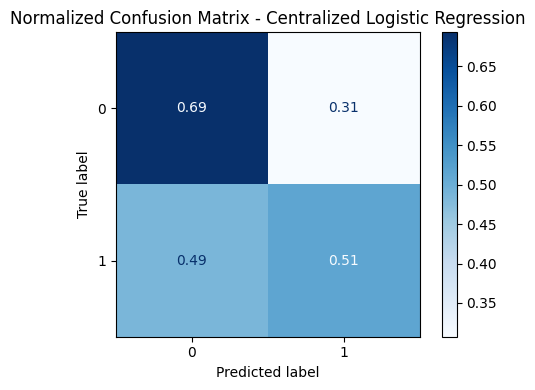

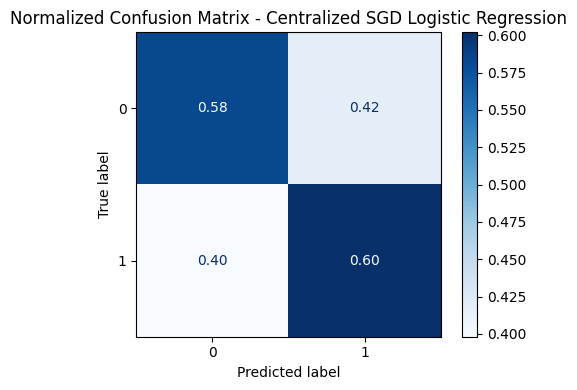

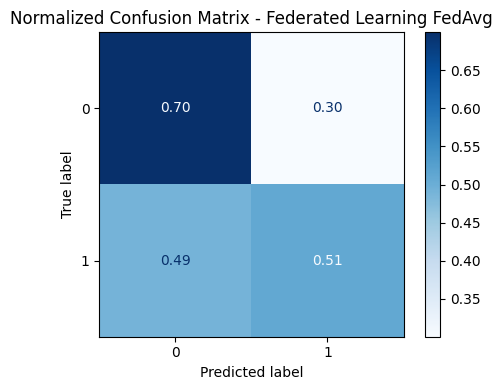

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, output in model_outputs.items():
    y_pred = output["y_pred"]

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test_common,
        y_pred,
        normalize="true",
        cmap="Blues",
        values_format=".2f",
        ax=ax
    )

    ax.set_title(f"Normalized Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

ROC Curve

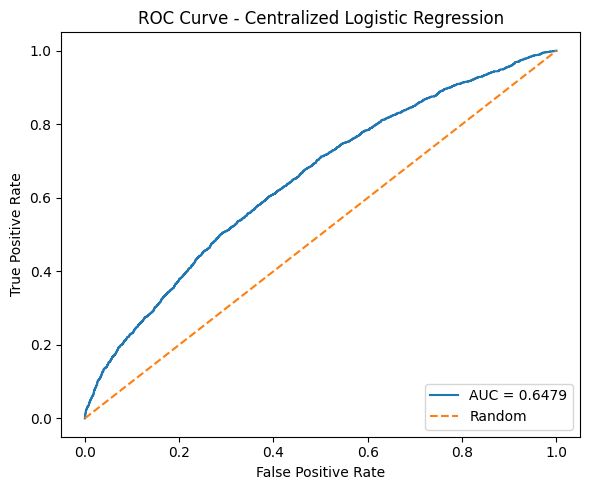

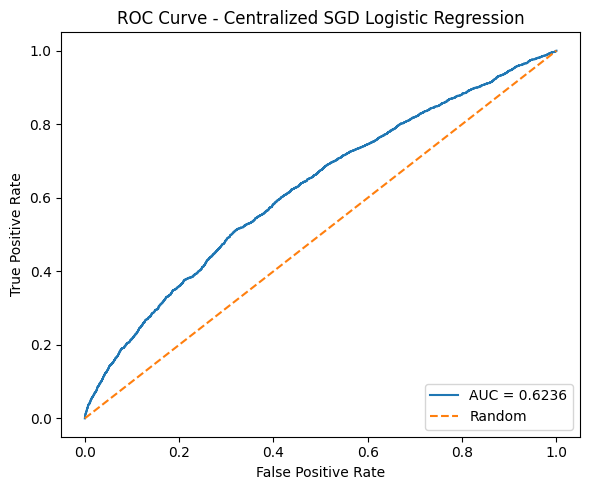

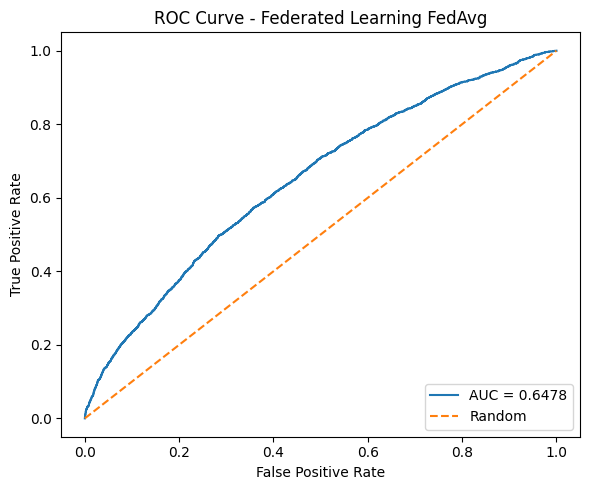

,model,roc_auc
0,Centralized Logistic Regression,0.647864
1,Centralized SGD Logistic Regression,0.623645
2,Federated Learning FedAvg,0.647801


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

roc_results = []

for model_name, output in model_outputs.items():
    y_prob = output["y_prob"]

    fpr, tpr, thresholds = roc_curve(y_test_common, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_results.append({
        "model": model_name,
        "roc_auc": roc_auc
    })

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve - {model_name}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

roc_results_df = pd.DataFrame(roc_results)
display(roc_results_df)

roc_results_df.to_csv("roc_auc_results.csv", index=False)

MPC 입력용 정수형 데이터 생성

In [ ]:
import numpy as np
import pandas as pd

scale_factor = 1000

def make_mpc_df(df):
    # 1. 중앙집중식/FL과 동일한 scaler 기준 적용
    X_scaled = scaler.transform(df[features])

    # 2. MPC 입력을 위해 정수화
    X_scaled_int = np.round(X_scaled * scale_factor).astype(int)

    # 3. target 붙이기
    y = df[target].astype(int).values.reshape(-1, 1)

    arr = np.hstack([X_scaled_int, y])

    return pd.DataFrame(arr, columns=features + [target])

mpc_A_train = make_mpc_df(A_train)
mpc_B_train = make_mpc_df(B_train)
mpc_C_train = make_mpc_df(C_train)

mpc_common_test = make_mpc_df(common_test)

print("MPC 입력용 정수 데이터 생성 완료")
print("mpc_A_train:", mpc_A_train.shape)
print("mpc_B_train:", mpc_B_train.shape)
print("mpc_C_train:", mpc_C_train.shape)
print("mpc_common_test:", mpc_common_test.shape)

MPC 입력용 정수 데이터 생성 완료
mpc_A_train: (27137, 20)
mpc_B_train: (27137, 20)
mpc_C_train: (27137, 20)
mpc_common_test: (20355, 20)


In [ ]:
# =========================
# MPC 입력 파일 저장
# =========================

mpc_A_train.to_csv("mpc_A_train.csv", index=False)
mpc_B_train.to_csv("mpc_B_train.csv", index=False)
mpc_C_train.to_csv("mpc_C_train.csv", index=False)
mpc_common_test.to_csv("mpc_common_test.csv", index=False)

print("MPC 입력 파일 저장 완료")

MPC 입력 파일 저장 완료


In [ ]:
print(mpc_A_train.head())
print(mpc_A_train.dtypes)

print("결측치 개수")
print(mpc_A_train.isna().sum().sum())
print(mpc_B_train.isna().sum().sum())
print(mpc_C_train.isna().sum().sum())
print(mpc_common_test.isna().sum().sum())

   race  gender   age  admission_type_id  discharge_disposition_id  \
0   272    -927  1193               -708                      -514   
1  3321    1078 -1939               -708                      -514   
2   272    1078 -1312               -708                      -514   
3 -1761    -927 -1312               -708                      -514   
4 -1761    -927 -1312               -708                      -514   

   admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  \
0                  305              -133                -668             386   
1                   59              -467                 503            -785   
2                  305              -802                 350            -785   
3                  305              -133                -108            -785   
4                  305             -1136                  45            -785   

   num_medications  number_outpatient  number_emergency  number_inpatient  \
0              120   

In [ ]:
# =========================
# 4. MP-SPDZ Player-Data 생성
# =========================

import os
import shutil

if os.path.exists("Player-Data"):
    shutil.rmtree("Player-Data")

os.makedirs("Player-Data", exist_ok=True)

def save_spdz_input(df, filename):
    values = []

    for _, row in df.iterrows():
        # feature 19개
        for col in features:
            values.append(int(row[col]))

        # label 1개
        values.append(int(row[target]))

    with open(filename, "w") as f:
        for v in values:
            f.write(str(v) + "\n")

save_spdz_input(mpc_A_train, "Player-Data/Input-P0-0")
save_spdz_input(mpc_B_train, "Player-Data/Input-P1-0")
save_spdz_input(mpc_C_train, "Player-Data/Input-P2-0")

print("MP-SPDZ 입력파일 생성 완료")

print("mpc_A_train:", mpc_A_train.shape)
print("mpc_B_train:", mpc_B_train.shape)
print("mpc_C_train:", mpc_C_train.shape)

print("P0 줄 수:", len(open("Player-Data/Input-P0-0").read().splitlines()))
print("P1 줄 수:", len(open("Player-Data/Input-P1-0").read().splitlines()))
print("P2 줄 수:", len(open("Player-Data/Input-P2-0").read().splitlines()))

MP-SPDZ 입력파일 생성 완료
mpc_A_train: (27137, 20)
mpc_B_train: (27137, 20)
mpc_C_train: (27137, 20)
P0 줄 수: 542740
P1 줄 수: 542740
P2 줄 수: 542740


In [ ]:
# =========================
# 5. Player-Data 압축
# =========================

shutil.make_archive("Player-Data", "zip", "Player-Data")

print("Player-Data.zip 생성 완료")

Player-Data.zip 생성 완료


In [5]:
import pandas as pd

df_mpc_test = pd.read_csv("/content/mpc_common_test.csv")

print(df_mpc_test.shape)
print(df_mpc_test.columns.tolist())
display(df_mpc_test.head())

(20355, 20)
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed', 'readmitted']


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,readmitted
0,272,-927,-59,-708,-136,305,-133,-261,-785,-249,-292,-208,-505,299,212,416,1902,-1077,546,0
1,272,-927,-686,2055,433,2765,-802,-973,-785,980,502,-208,290,815,-2032,416,-1672,-1077,546,0
2,272,-927,-1312,-708,-514,305,-1136,-923,-785,-1110,-292,-208,-505,-1766,212,416,-481,-1077,546,0
3,272,-927,-59,673,2706,-1171,-467,-1177,-200,242,-292,-208,-505,-2283,212,416,-481,-1077,546,1
4,272,1078,-59,-18,-514,305,-1136,401,-785,-126,502,-208,-505,815,212,416,710,-1077,546,0


MPC 성능 평가

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
)

# =========================
# 1. 변수 설정
# =========================

features = [
    'race',
    'gender',
    'age',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'max_glu_serum',
    'A1Cresult',
    'insulin',
    'change',
    'diabetesMed'
]

target = "readmitted"

# MPC 평가용 공통 test set
df_mpc_test = pd.read_csv("/content/mpc_common_test.csv")

X_mpc_test = df_mpc_test[features].values
y_mpc_test = df_mpc_test[target].astype(int).values

# =========================
# 2. MPC-SGD 1 epoch 결과 입력
# =========================

bias = -2.06062

weights = np.array([
    -0.00865173,
    0.00480652,
    0.0204163,
    -0.0123749,
    0.0697937,
    -0.00679016,
    0.035202,
    0.0158691,
    -0.0225067,
    0.0336151,
    0.0126953,
    0.0685577,
    0.253281,
    0.0548553,
    -0.0108795,
    0.0204315,
    -0.00384521,
    -0.0148621,
    0.0388489
])

# MP-SPDZ에서 사용한 선형 sigmoid 근사
def sigmoid_approx(z):
    return 0.5 + 0.125 * z

# =========================
# 3. 예측 수행
# =========================

z = bias + np.dot(X_mpc_test, weights)
y_prob_mpc_1epoch = sigmoid_approx(z)

# 선형 근사는 0~1 범위를 벗어날 수 있으므로 보정
y_prob_mpc_1epoch = np.clip(y_prob_mpc_1epoch, 0, 1)

# threshold 0.5 기준 분류
y_pred_mpc_1epoch = (y_prob_mpc_1epoch >= 0.5).astype(int)

# =========================
# 4. 성능 지표 출력
# =========================

acc = accuracy_score(y_mpc_test, y_pred_mpc_1epoch)
precision = precision_score(y_mpc_test, y_pred_mpc_1epoch, zero_division=0)
recall = recall_score(y_mpc_test, y_pred_mpc_1epoch, zero_division=0)
f1 = f1_score(y_mpc_test, y_pred_mpc_1epoch, zero_division=0)
roc_auc = roc_auc_score(y_mpc_test, y_prob_mpc_1epoch)

print("===== MPC SGD Logistic Regression 1 Epoch =====")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nConfusion Matrix")
print(confusion_matrix(y_mpc_test, y_pred_mpc_1epoch))

print("\nClassification Report")
print(classification_report(y_mpc_test, y_pred_mpc_1epoch, zero_division=0))

===== MPC SGD Logistic Regression 1 Epoch =====
Accuracy : 0.6324735937116188
Precision: 0.16585428424833248
Recall   : 0.5693527080581242
F1-score : 0.256878911294328
ROC-AUC  : 0.6060055764035168

Confusion Matrix
[[11581  6503]
 [  978  1293]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.64      0.76     18084
           1       0.17      0.57      0.26      2271

    accuracy                           0.63     20355
   macro avg       0.54      0.60      0.51     20355
weighted avg       0.84      0.63      0.70     20355



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
)

features = [
    'race',
    'gender',
    'age',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'max_glu_serum',
    'A1Cresult',
    'insulin',
    'change',
    'diabetesMed'
]

target = "readmitted"

df_mpc_test = pd.read_csv("/content/mpc_common_test.csv")

print("MPC test shape:", df_mpc_test.shape)
print("columns:", df_mpc_test.columns.tolist())

X_mpc_test = df_mpc_test[features].values
y_mpc_test = df_mpc_test[target].astype(int).values

# =========================
# MPC-SGD 2 epoch 결과
# =========================

bias = -2.75354

weights = np.array([
    -0.0075531,
    0.0121307,
    0.0309906,
    -0.0151978,
    0.0891724,
    -0.0124207,
    0.0414734,
    0.0124817,
    -0.0329285,
    0.0310516,
    0.00556946,
    0.0701447,
    0.332764,
    0.0541992,
    -0.0167847,
    0.0209198,
    -0.00386047,
    -0.0165253,
    0.0448914
])

# MP-SPDZ 학습 코드에서 사용한 선형 sigmoid 근사
def sigmoid_approx(z):
    return 0.5 + 0.125 * z

z = bias + np.dot(X_mpc_test, weights)
y_prob_mpc = sigmoid_approx(z)

# 선형 근사는 0~1 범위를 벗어날 수 있으므로 보정
y_prob_mpc = np.clip(y_prob_mpc, 0, 1)

# threshold 0.5 기준 분류
y_pred_mpc = (y_prob_mpc >= 0.5).astype(int)

acc = accuracy_score(y_mpc_test, y_pred_mpc)
precision = precision_score(y_mpc_test, y_pred_mpc, zero_division=0)
recall = recall_score(y_mpc_test, y_pred_mpc, zero_division=0)
f1 = f1_score(y_mpc_test, y_pred_mpc, zero_division=0)
roc_auc = roc_auc_score(y_mpc_test, y_prob_mpc)

print("===== MPC SGD Logistic Regression 2 Epoch =====")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nConfusion Matrix")
print(confusion_matrix(y_mpc_test, y_pred_mpc))

print("\nClassification Report")
print(classification_report(y_mpc_test, y_pred_mpc, zero_division=0))

MPC test shape: (20355, 20)
columns: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'insulin', 'change', 'diabetesMed', 'readmitted']
===== MPC SGD Logistic Regression 2 Epoch =====
Accuracy : 0.6435273888479489
Precision: 0.1691225275454666
Recall   : 0.5609863496257156
F1-score : 0.2598939208486332
ROC-AUC  : 0.6076465437333347

Confusion Matrix
[[11825  6259]
 [  997  1274]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.65      0.77     18084
           1       0.17      0.56      0.26      2271

    accuracy                           0.64     20355
   macro avg       0.55      0.61      0.51     20355
weighted avg       0.84      0.64      0.71     20355



MPC 정규화 Confusion Matrix

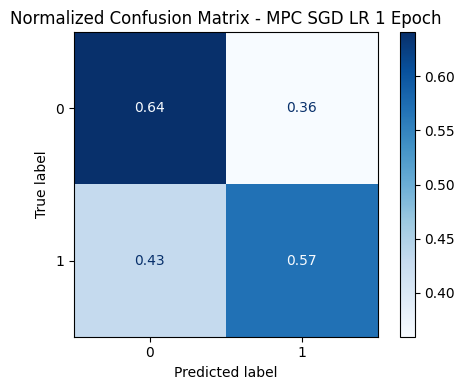

In [12]:
# =========================
# Normalized Confusion Matrix - 1 epoch
# =========================

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_mpc_test,
    y_pred_mpc_1epoch,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax
)

ax.set_title("Normalized Confusion Matrix - MPC SGD LR 1 Epoch")
plt.tight_layout()
plt.show()

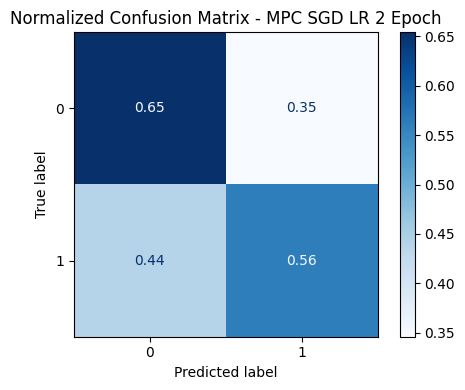

In [13]:
# Normalized Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_mpc_test,
    y_pred_mpc,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax
)

ax.set_title("Normalized Confusion Matrix - MPC SGD LR 2 Epoch")
plt.tight_layout()
plt.show()


MPC ROC Curve

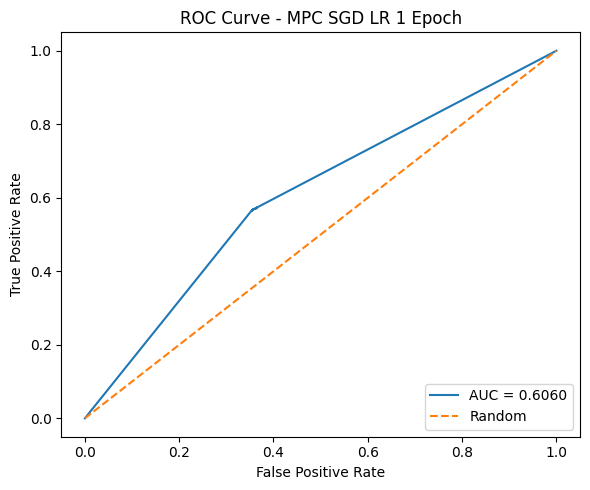

In [14]:
# =========================
# ROC Curve - 1 epoch
# =========================

fpr, tpr, thresholds = roc_curve(y_mpc_test, y_prob_mpc_1epoch)
roc_auc_value = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - MPC SGD LR 1 Epoch")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

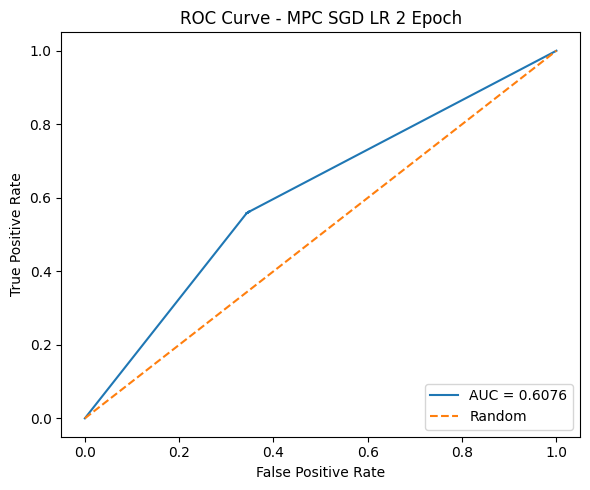

In [15]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_mpc_test, y_prob_mpc)
roc_auc_value = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - MPC SGD LR 2 Epoch")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()